In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("Diabetes dataset.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
num_rows, num_cols = df.shape
print('Number of rows:', num_rows)
print('Number of columns:', num_cols)

Number of rows: 768
Number of columns: 9


In [ ]:
column_names = df.columns.tolist()
data_types = df.dtypes.tolist()
print('Column names:', column_names)
print('Data types:', data_types)

Column names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Data types: [dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('float64'), dtype('float64'), dtype('int64'), dtype('int64')]


In [ ]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
summary_stats = df[numeric_cols].describe()
print('Summary statistics:')
print(summary_stats)

Summary statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.0000

In [ ]:
X = df.drop(['Outcome', 'BMI', 'DiabetesPedigreeFunction'	], axis = 1).values.reshape(-1, 6) # here I drop these three column mentioned in code
y = df['Outcome'].values.reshape(-1, 1)
X, y[:5]

(array([[  6, 148,  72,  35,   0,  50],
        [  1,  85,  66,  29,   0,  31],
        [  8, 183,  64,   0,   0,  32],
        ...,
        [  5, 121,  72,  23, 112,  30],
        [  1, 126,  60,   0,   0,  47],
        [  1,  93,  70,  31,   0,  23]]),
 array([[1],
        [0],
        [1],
        [0],
        [1]]))

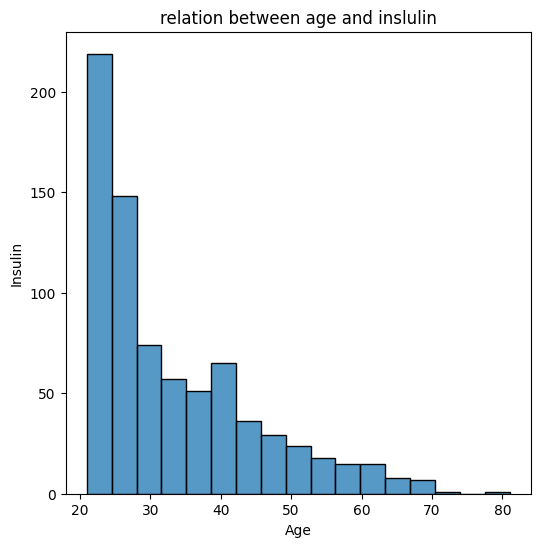

In [ ]:
plt.figure(figsize=(6,6))
sns.histplot(df['Age'])
plt.title('relation between age and inslulin')
plt.xlabel('Age')
plt.ylabel('Insulin')
plt.show()

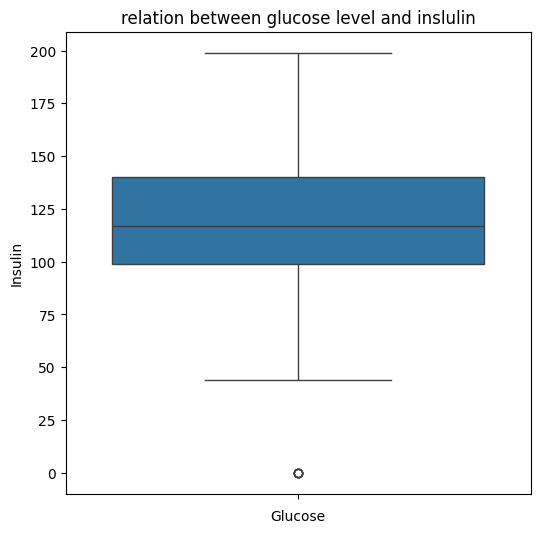

In [ ]:
plt.figure(figsize=(6,6))
sns.boxplot(df['Glucose'])
plt.title('relation between glucose level and inslulin')
plt.xlabel('Glucose')
plt.ylabel('Insulin')
plt.show()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=6)

In [ ]:
reg = LinearRegression()

In [ ]:
model = reg.fit(x_train, y_train)

In [ ]:
y_pred = model.predict(x_test).round()

In [ ]:
print(y_test[:5])
print(y_pred[:5])

[[0]
 [1]
 [0]
 [0]
 [0]]
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]]


In [ ]:
from sklearn.metrics import accuracy_score # I don't know how to check accuracy of model so that i used this method with help of Stack_Over_Flow
print(f"{accuracy_score(y_test, y_pred)*100} %")

78.57142857142857 %


In [ ]:
def diabetes_prediction():
  #Pregnancies	Glucose	BloodPressure	SkinThickness	Insulin	Age
  preg = int(input("Enter the prega value:"))
  glu = int(input("Enter the glu value:"))
  BP = int(input("Enter the BP value:"))
  SkinThik = int(input("Enter the SkinThink value:"))
  Insulin = int(input("Enter the Insulin value:"))
  Age = int(input("Enter the Age value:"))
  Value_testing = np.array([preg, glu, BP, SkinThik, Insulin, Age]).reshape(-1, 6)
   # 1st I wrote list but then i got error that was "expected 2D array",
   #to overcome this issue i convert list into numpy array using (np.array) with the help of stackoverflow
  prediction = model.predict(Value_testing).round()
  print(prediction)
  if prediction ==1:
    print("You are diabetic")
  else:
    print("You are non-Diabetic")
#6	148	72	35	0	33.6	0.627	50	1


#1	85	66	29	0	26.6	0.351	31	0

In [ ]:
diabetes_prediction()


[[1.]]
You are diabetic
